In [ ]:
# Data Cleaning and Visualization

## Titanic Dataset

### Objective
The objective of this project is to clean and analyze the Titanic dataset and create meaningful visualizations using Python.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Display information about the dataset
# This shows the number of rows, columns, data types, and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
# Check the number of missing values in each column
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [7]:
# Check duplicate rows in the dataset
df.duplicated().sum()

np.int64(107)

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new size
df.shape

(784, 15)

In [9]:
# Check whether duplicate rows are still present
df.duplicated().sum()

np.int64(0)

In [10]:
# Get statistical summary of numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,784.000000,784.000000,678.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,29.869351,0.522959,0.415816,34.711740
std,0.492507,0.855056,14.759076,0.986231,0.836922,52.160151
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.250000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.109350
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Check missing values in each column
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,106
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [12]:
# Fill missing age values with the median age
df['age'] = df['age'].fillna(df['age'].median())
# Check missing values in age column
df['age'].isnull().sum()

np.int64(0)

In [13]:
# Fill missing embarked values with the most common value
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embarked'].isnull().sum()

np.int64(0)

In [14]:
# Fill missing embark_town values with the most common value
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embark_town'].isnull().sum()

np.int64(0)

In [15]:
# Drop deck because it contains too many missing values
# deck has 582 missing values out of 784
df = df.drop('deck', axis=1)

In [16]:
# Check missing values after cleaning
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [28]:
# Check the final number of rows and columns
df.shape

(784, 14)

In [39]:
# Select numerical columns for outlier checking
num_cols = ['age', 'fare', 'sibsp', 'parch']

# Check outliers in each numerical column
for col in num_cols:

    # Calculate the first quartile (Q1)
    Q1 = df[col].quantile(0.25)

    # Calculate the third quartile (Q3)
    Q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Calculate the lower limit
    lower_bound = Q1 - 1.5 * IQR

    # Calculate the upper limit
    upper_bound = Q3 + 1.5 * IQR

    # Find values outside the limits
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Display the number of outliers
    print(col, ":", len(outliers), "outliers")

age : 11 outliers
fare : 116 outliers
sibsp : 46 outliers
parch : 213 outliers


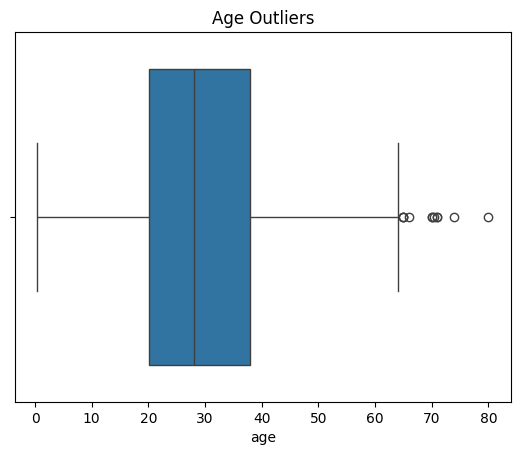

In [40]:
# Create a boxplot for age
sns.boxplot(x=df['age'])

# Add title
plt.title('Age Outliers')

# Display the graph
plt.show()

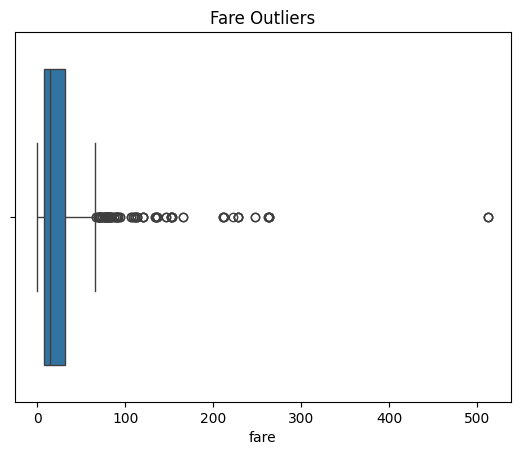

In [41]:
# Create a boxplot for fare
sns.boxplot(x=df['fare'])

# Add title
plt.title('Fare Outliers')

# Display the graph
plt.show()

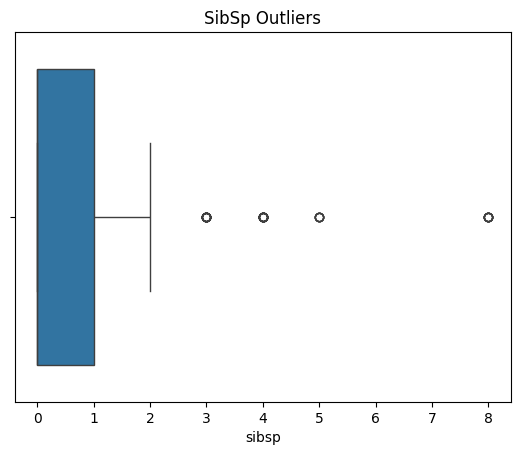

In [42]:
# Create a boxplot for SibSp
sns.boxplot(x=df['sibsp'])

# Add title
plt.title('SibSp Outliers')

# Display the graph
plt.show()

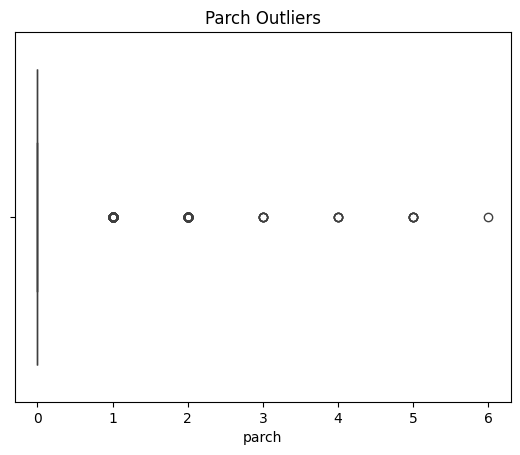

In [43]:
# Create a boxplot for Parch
sns.boxplot(x=df['parch'])

# Add title
plt.title('Parch Outliers')

# Display the graph
plt.show()

In [17]:
# Count the number of passengers who survived and did not survive
df['survived'].value_counts()

,count
survived,
0,461
1,323


In [18]:
# Calculate the percentage of passengers who survived and did not survive
df['survived'].value_counts(normalize=True) * 100

,proportion
survived,
0,58.80102
1,41.19898


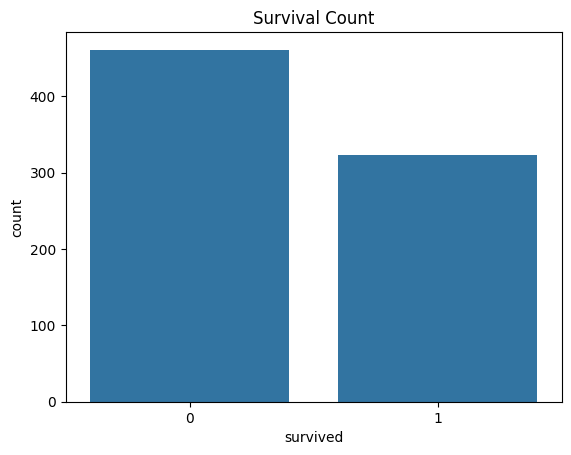

In [31]:
# Plot the number of survived and non-survived passengers
sns.countplot(x='survived', data=df)

# Add title to the graph
plt.title('Survival Count')

# Display the graph
plt.show()

In [19]:
# Count male and female passengers
df['sex'].value_counts()

,count
sex,
male,491
female,293


In [20]:
# Calculate the percentage of male and female passengers
df['sex'].value_counts(normalize=True) * 100

,proportion
sex,
male,62.627551
female,37.372449


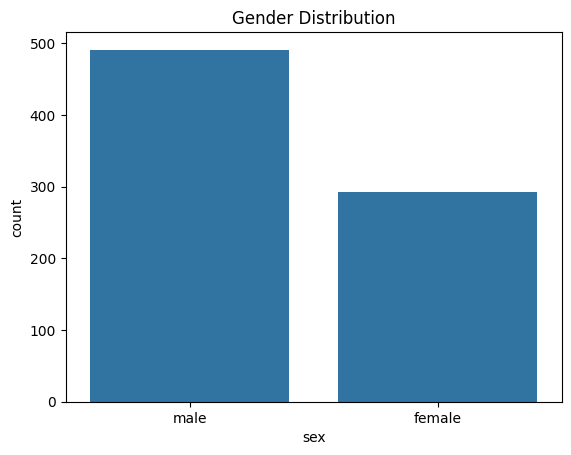

In [21]:
# Plot the number of male and female passengers
sns.countplot(x='sex', data=df)

# Add title
plt.title('Gender Distribution')

# Display the graph
plt.show()


In [22]:
# Count passengers in each passenger class
df['pclass'].value_counts()

,count
pclass,
3,405
1,214
2,165


In [23]:
# Calculate the percentage of passengers in each class
df['pclass'].value_counts(normalize=True) * 100

,proportion
pclass,
3,51.658163
1,27.295918
2,21.045918


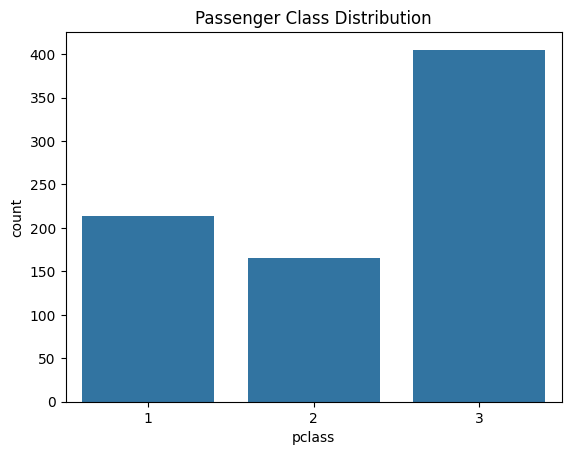

In [24]:
# Plot the number of passengers in each class
sns.countplot(x='pclass', data=df)

# Add title
plt.title('Passenger Class Distribution')

# Display the graph
plt.show()

In [25]:
# Display basic statistics of age
df['age'].describe()


,age
count,784.000000
mean,29.650408
std,13.734925
min,0.420000
25%,22.000000
50%,28.250000
75%,36.000000
max,80.000000


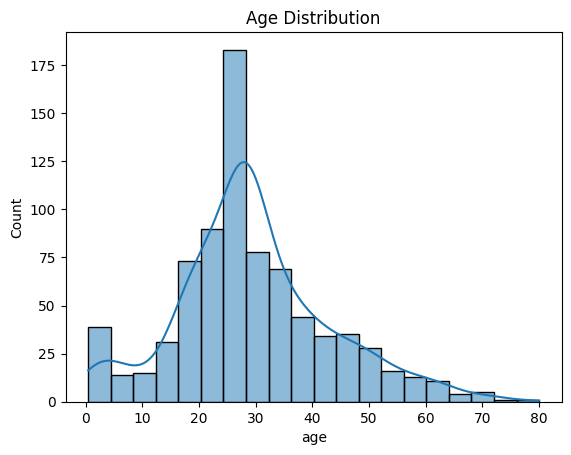

In [26]:
# Plot the distribution of passenger ages
sns.histplot(df['age'], bins=20, kde=True)

# Add title
plt.title('Age Distribution')

# Display the graph
plt.show()

In [27]:
# Display basic statistics of passenger fare
df['fare'].describe()

,fare
count,784.000000
mean,34.711740
std,52.160151
min,0.000000
25%,8.050000
50%,15.900000
75%,34.109350
max,512.329200


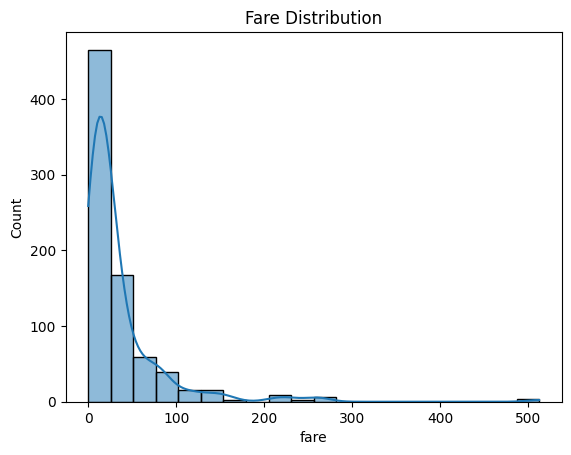

In [28]:
# Plot the distribution of passenger fares
sns.histplot(df['fare'], bins=20, kde=True)

# Add title
plt.title('Fare Distribution')

# Display the graph
plt.show()

In [29]:
# Count survivors and non-survivors for each gender
pd.crosstab(df['sex'], df['survived'])

survived,0,1
sex,,
female,76,217
male,385,106


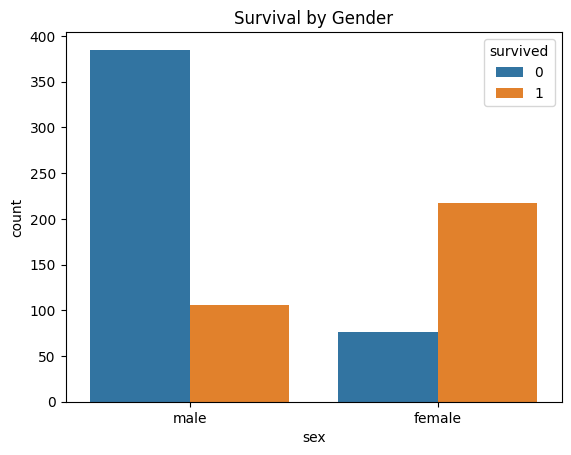

In [30]:
# Plot survival based on gender
sns.countplot(x='sex', hue='survived', data=df)

# Add title
plt.title('Survival by Gender')

# Display the graph
plt.show()

In [33]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")
# Count survivors and non-survivors for each passenger class
pd.crosstab(df['pclass'], df['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


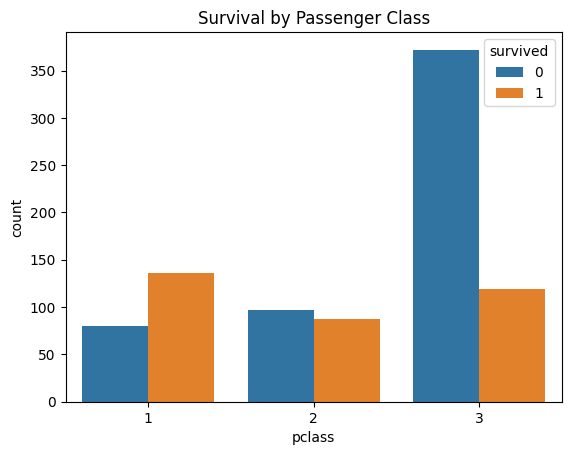

In [34]:
# Plot survival based on passenger class
sns.countplot(x='pclass', hue='survived', data=df)

# Add title
plt.title('Survival by Passenger Class')

# Display the graph
plt.show()

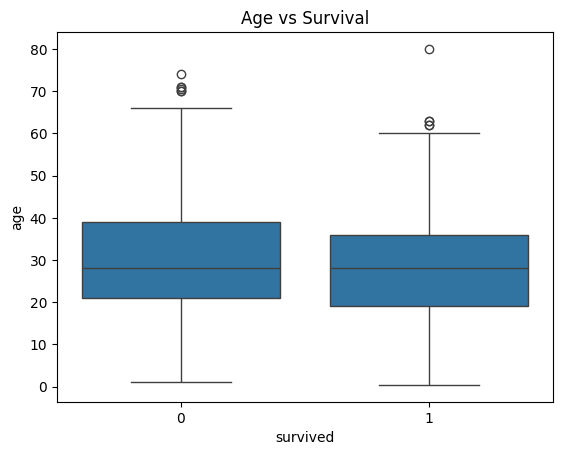

In [35]:
# Plot age distribution for survivors and non-survivors
sns.boxplot(x='survived', y='age', data=df)

# Add title
plt.title('Age vs Survival')

# Display the graph
plt.show()

In [36]:
# Count survivors and non-survivors for each embarkation port
pd.crosstab(df['embarked'], df['survived'])

survived,0,1
embarked,,
C,75,93
Q,47,30
S,427,217


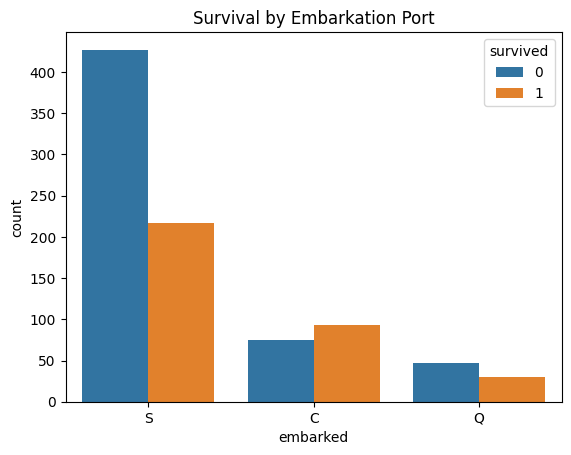

In [37]:
# Plot survival based on embarkation port
sns.countplot(x='embarked', hue='survived', data=df)

# Add title
plt.title('Survival by Embarkation Port')

# Display the graph
plt.show()

In [38]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation between numerical columns
correlation = numeric_df.corr()

# Display the correlation matrix
correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
# Create a boxplot for age
sns.boxplot(x=df['age'])

# Add title
plt.title('Age Outliers')

# Display the graph
plt.show()

## Key Findings

1. **Passenger Distribution:** Most passengers were from **3rd class**, followed by 1st class and 2nd class.

2. **Survival Rate:** A smaller proportion of passengers survived compared to those who did not survive.

3. **Gender and Survival:** **Female passengers had a higher survival rate** compared to male passengers.

4. **Passenger Class and Survival:** **1st-class passengers had a higher chance of survival**, while 3rd-class passengers had a lower survival rate.

5. **Age Distribution:** Most passengers were **young and middle-aged adults**, with fewer very young children and elderly passengers.

6. **Fare Distribution:** The fare data was **right-skewed**, meaning most passengers paid lower fares while a smaller number paid very high fares.

7. **Family Information:** The `sibsp` and `parch` columns show that passengers had different family sizes, with many passengers travelling with few or no family members.

8. **Outliers:** Outliers were identified mainly in **Age, Fare, SibSp, and Parch**. These were handled during data preprocessing.

9. **Data Quality:** After handling missing values and outliers, the dataset was checked to ensure it was suitable for further analysis.


## Conclusion

The Titanic dataset was successfully explored and cleaned using Exploratory Data Analysis (EDA). Missing values were handled, important patterns were identified through visualizations, and outliers were detected and handled. The analysis showed clear differences in survival based on gender and passenger class. Overall, EDA helped us understand the dataset and identify important factors related to passenger survival.
